 Przykład 1
 Optymalizacja KNN
 To zadanie pokaże Ci, jak jeden parametr (liczba sąsiadów) może zmienić wszystko.
 Treść:
 Wytrenuj model KNN na tym samym zbiorze Wine, ale sprawdź jego skuteczność dla różnych wartości K (liczby sąsiadów): 1, 3, 5, 11, 20.
 Wymagania:
 - Wydrukuj wynik dla każdego $K$.
 - Napisz, która wartość $K$ dała najlepszy wynik.
 Logika do przemyślenia:
 - $K=1$: Model jest bardzo "nerwowy". Patrzy tylko na jednego, najbliższego sąsiada. Jeśli ten sąsiad to outlier (błąd), model też się pomyli.
 - Duże $K$ (np. 20): Model jest "leniwy". Bierze pod uwagę zbyt wielu sąsiadów, przez co może zacząć ignorować lokalne różnice między gatunkami win.

Wnioski: 
KNN działa jak głosowanie sąsiadów:
- K=1: Jest bardzo podatny na "szum". Jeśli jedno wino z klasy A leży przypadkiem blisko win z klasy B, model przy $K=1$ zawsze się pomyli.
- K=11 czy 20: Model staje się bardziej "demokratyczny". Głos większości wygrywa, co zazwyczaj daje bardziej stabilne wyniki, chyba że przesadzimy i weźmiemy pod uwagę sąsiadów z drugiego końca mapy.

co się stało:
- Dla małych wartości ($K=1, 3, 5$) miałaś stabilne 97%. To oznacza, że model radził sobie świetnie, ale gdzieś na granicy gatunków win trafiał na pojedynczą próbkę, która go myliła.Dla większych wartości ($K=11, 20$) wskoczyłaś na idealne 100% (1.0000)!
- Dlaczego większe K zadziałało lepiej?
W przypadku tego zbioru danych (Wine), zwiększenie liczby sąsiadów zadziałało jak filtr antyszumowy.
1. Głosowanie większości: Przy $K=11$, pojedynczy "dziwny" przypadek (outlier), który leży blisko granicy innego gatunku, zostaje przegłosowany przez 10 pozostałych, poprawnych sąsiadów.
2. Stabilność: Im więcej sąsiadów bierzesz pod uwagę, tym bardziej "odporna" na błędy staje się granica między klasami. Dla win z tego datasetu cechy są na tyle wyraźne, że nawet 20 najbliższych sąsiadów wciąż pochodzi z tej samej grupy, co pozwala modelowi na bezbłędną decyzję.

Mała przestroga (Wnioski analityka)Mimo że $K=20$ dało 100%, nie zawsze "im więcej, tym lepiej". Gdybyś ustawiła $K=100$ (przy tak małym zbiorze), model zacząłby wybierać po prostu najliczniejszą grupę w całym zbiorze, ignorując lokalne cechy wina. Znalazłaś tutaj tzw. "Sweet Spot" (złoty środek).

In [39]:
k_values = [1, 3, 5, 11, 20]


# 2. Podział danych
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Standaryzacja (BARDZO ważna dla KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Pętla po różnych wartościach K
results = []

for k in k_values:
    # Tworzymy model z konkretnym K
    knn = KNeighborsClassifier(n_neighbors=k)
    
    # Trenujemy i oceniamy TEN konkretny model knn
    knn.fit(X_train_scaled, y_train)
    accuracy = knn.score(X_test_scaled, y_test)
    
    # Zapisujemy wynik, używając k jako nazwy
    results.append({"K": k, "Accuracy": f"{accuracy:.4f}"})

# 5. Wydruk wyników
df_results = pd.DataFrame(results)
print("\n=== OPTYMALIZACJA KNN (WINE DATASET) ===")
print(df_results.to_string(index=False))


=== OPTYMALIZACJA KNN (WINE DATASET) ===
 K Accuracy
 1   0.9722
 3   0.9722
 5   0.9722
11   1.0000
20   1.0000


Przykład 2 
Drzewa Decyzyjne (Głębokość)
Wytrenuj model DecisionTreeClassifier na zbiorze Wine, sprawdzając głębokość drzewa: 1, 2, 3, 5, 10.

Analiza wyników:
Głębokość 1 (Accuracy: 0.5833): To podręcznikowy Underfitting (niedopasowanie). Drzewo zadało tylko jedno pytanie (np. „Czy alkohol > 13?”). To za mało, żeby rozróżnić trzy gatunki win, dlatego wynik jest niewiele lepszy od rzutu monetą.

Głębokość 2 (Accuracy: 0.8611): Drzewo dołożyło drugie piętro pytań. Skuteczność drastycznie skoczyła w górę – model zaczął zauważać kluczowe różnice.

Głębokość 3 (Accuracy: 0.9444): Tutaj osiągnęłaś "Sweet Spot". Drzewo jest na tyle rozbudowane, by świetnie rozumieć dane, ale nie na tyle, by zacząć „szukać dziury w całym”.

Głębokość 5 i 10 (Accuracy: 0.9444): Zauważ, że wynik przestał rosnąć. To oznacza, że dla tego zestawu danych 3 pytania (poziomy) wystarczą, by wycisnąć z nich wszystko, co ważne. Dalsze pogłębianie drzewa nic już nie wnosi – model po prostu powiela te same decyzje

In [38]:
depths = [1, 2, 3, 5, 10]
results = []

for d in depths:
    dtc = DecisionTreeClassifier(max_depth=d, random_state=42)
    dtc.fit(X_train_scaled, y_train)
    accuracy = dtc.score(X_test_scaled, y_test)
    
    results.append({"Głębokość (d)": d, "Accuracy": f"{accuracy:.4f}"})

df_results = pd.DataFrame(results)
print("\n=== OPTYMALIZACJA DRZEWA (WINE DATASET) ===")
print(df_results.to_string(index=False))


=== OPTYMALIZACJA DRZEWA (WINE DATASET) ===
 Głębokość (d) Accuracy
             1   0.5833
             2   0.8611
             3   0.9444
             5   0.9444
            10   0.9444


Podsumowanie 
KNN ($K=11$ lub $20$): 1.0000 (Zwycięzca!)
Logistic Regression: 0.9722
Decision Tree ($d \ge 3$): 0.9444W tym konkretnym przypadku (Wine Dataset) KNN okazał się bezkonkurencyjny, gdy daliśmy mu wystarczająco dużo sąsiadów do "przegłosowania" błędów.

Zadanie 1 – Pierwszy model klasyfikacji
Wytrenuj model LogisticRegression na datasecie Iris i oceń jego accuracy.
Dataset: sklearn.datasets.load_iris()

Wymagania:
- Podziel dane 80/20 (train/test)
- Zastosuj standaryzację
- Wydrukuj accuracy na zbiorze testowym


Rozmiar: 150 próbek, 4 cech
Odmiany irisa: ['setosa' 'versicolor' 'virginica']
Rozkład odmian irisa: [50 50 50]

Podział danych:
 Train: 120 próbek
 Test: 30 próbek

Po standaryzacji:
 Mean (train): -0.000000
 Std (train): 1.000000

Model wytrenowany!
 Liczba iteracji: 16

Accuracy na zbiorze testowym: 0.93


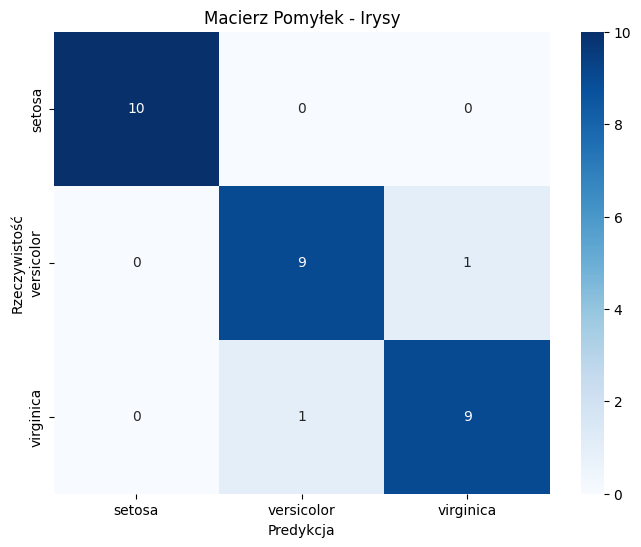


Szczegółowy Raport Klasyfikacji:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Wczytanie danych
iris = load_iris()
X, y = iris.data, iris.target

print(f"\nRozmiar: {X.shape[0]} próbek, {X.shape[1]} cech")
print(f"Odmiany irisa: {iris.target_names}")
print(f"Rozkład odmian irisa: {np.bincount(y)}")

# Podział na zbiór treningowy i testowy:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% na test
    random_state=42,     # dla reprodukowalności
    stratify=y           # zachowanie proporcji klas
)

print(f"\nPodział danych:")
print(f" Train: {X_train.shape[0]} próbek")
print(f" Test: {X_test.shape[0]} próbek")

# Standaryzacja:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nPo standaryzacji:")
print(f" Mean (train): {X_train_scaled.mean():.6f}")
print(f" Std (train): {X_train_scaled.std():.6f}")

# Trening modelu:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print(f"\nModel wytrenowany!")
print(f" Liczba iteracji: {model.n_iter_[0]}")

# Ocena (Accuracy):
accuracy = model.score(X_test_scaled, y_test)
print(f"\nAccuracy na zbiorze testowym: {accuracy:.2f}")

# Generujemy macierz
cm = confusion_matrix(y_test, model.predict(X_test_scaled))

# Wyświetlamy ją w czytelny sposób
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=iris.target_names, 
            yticklabels=iris.target_names)
plt.xlabel('Predykcja')
plt.ylabel('Rzeczywistość')
plt.title('Macierz Pomyłek - Irysy')
plt.show()

print("\nSzczegółowy Raport Klasyfikacji:")
print(classification_report(y_test, model.predict(X_test_scaled), 
                            target_names=iris.target_names))

Zadanie 2 – Porównanie trzech algorytmów
Porównaj accuracy trzech algorytmów na datasecie Wine: LogisticRegression,
DecisionTree, KNN.

Dataset: sklearn.datasets.load_wine()

Wymagania:
- Ten sam podział train/test dla wszystkich
- Wydrukuj wyniki w formie tabeli

Wrażliwość na skalowanie: Drzewa Decyzyjne nie potrzebują standaryzacji (radzą sobie z surowymi danymi tak samo dobrze), ale dla Regresji Logistycznej i KNN jest ona krytyczna. Dzięki temu, że przeskalowaliśmy wszystko, każdy model startuje z tej samej pozycji.

Dataset Wine: To zbiór trudniejszy niż Iris, bo ma więcej cech (13) i wina są do siebie bardziej zbliżone składem chemicznym.

In [ ]:
# Scikit-learn ma spójny interfejs dla WSZYSTKICH algorytmów:
# 1. fit(X, y) - uczenie modelu na danych
# 2. predict(X) - predykcja dla nowych danych
# 3. score(X, y) - ewaluacja modelu
# 4. transform(X) - transformacja danych (dla preprocessorów)

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# 1. Wczytanie danych
wine = load_wine()
X, y = wine.data, wine.target

# 2. Podział danych (wspólny dla wszystkich modeli)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Standaryzacja (kluczowa dla LogReg i KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Definicja modeli
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN (K=5)": KNeighborsClassifier(n_neighbors=5)
}

# 5. Pętla treningowa i zbieranie wyników
results = []

for name, model in models.items():
    # Używamy danych skalowanych dla wszystkich, by było sprawiedliwie
    model.fit(X_train_scaled, y_train)
    accuracy = model.score(X_test_scaled, y_test)
    results.append({"Algorytm": name, "Accuracy": f"{accuracy:4f}"})

# 6. Wydruk wyników w formie tabeli
df_results = pd.DataFrame(results)
print("\n=== PORÓWNANIE ALGORYTMÓW (WINE DATASET) ===")
print(df_results.to_string(index=False))


=== PORÓWNANIE ALGORYTMÓW (WINE DATASET) ===
           Algorytm Accuracy
Logistic Regression 0.972222
      Decision Tree 0.944444
          KNN (K=5) 0.972222


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: divide by zero encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: overflow encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: invalid value encountered in matmul
  grad[:, :n_features] = grad_pointwise.T @ X + l2_reg_strength * weights


Pamiętaj, że KNN działa jak głosowanie sąsiadów:
- K=1: Jest bardzo podatny na "szum". Jeśli jedno wino z klasy A leży przypadkiem blisko win z klasy B, model przy $K=1$ zawsze się pomyli.
- K=11 czy 20: Model staje się bardziej "demokratyczny". Głos większości wygrywa, co zazwyczaj daje bardziej stabilne wyniki, chyba że przesadzimy i weźmiemy pod uwagę sąsiadów z drugiego końca mapy.

Zadanie 3 – Confusion Matrix
Dla klasyfikacji binarnej na Breast Cancer dataset, stwórz i zwizualizuj confusion matrix.
Dataset: sklearn.datasets.load_breast_cancer()
Wymagania:
- Użyj Random Forest
- Heatmap confusion matrix z annotacjami
- Oblicz precision, recall, F1

=== METRYKI (BREAST CANCER) ===
Precision: 0.9589
Recall:    0.9722
F1-Score:  0.9655


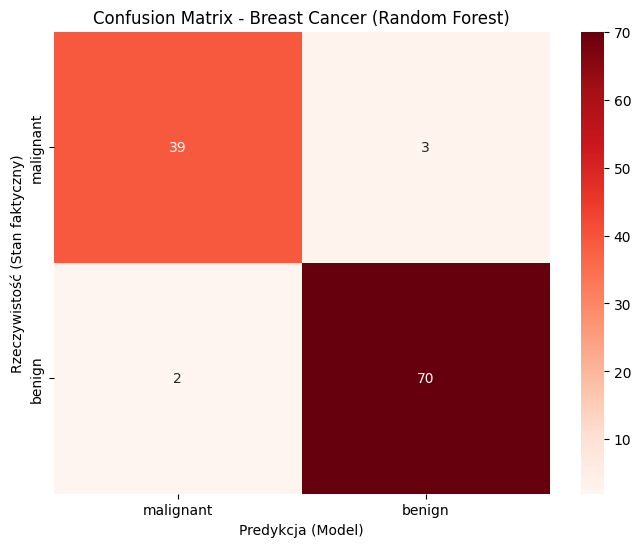


Pełny raport klasyfikacji:
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score

# 1. Wczytanie danych
data = load_breast_cancer()
X, y = data.data, data.target

# 2. Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Random Forest (nie wymaga skalowania danych)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 4. Obliczanie metryk
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"=== METRYKI (BREAST CANCER) ===")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# 5. Wizualizacja Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=data.target_names, 
            yticklabels=data.target_names)
plt.xlabel('Predykcja (Model)')
plt.ylabel('Rzeczywistość (Stan faktyczny)')
plt.title('Confusion Matrix - Breast Cancer (Random Forest)')
plt.show()

# 6. Pełny raport dla pewności
print("\nPełny raport klasyfikacji:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Zadanie 4 – Regresja liniowa
Przeprowadź regresję liniową na California Housing i oceń R².

Dataset: sklearn.datasets.fetch_california_housing()

Wymagania:
- Standaryzacja cech
- Oblicz RMSE i R²
- Scatter plot: predicted vs actual

Na co zwrócić uwagę w tym zadaniu?
1. Interpretacja R² (R-kwadrat):
To najważniejsza miara w regresji. Mówi nam, w ilu procentach model wyjaśnia zmienność danych.
- Jeśli $R^2 = 0.60$, oznacza to, że Twoje cechy (położenie, liczba pokoi itp.) tłumaczą 60% ceny domu. Pozostałe 40% to czynniki, których nie ma w tabeli.

2. RMSE (Root Mean Squared Error):Mówi o tym, o ile średnio model "myli się" w przewidywaniu ceny. Ponieważ ceny w tym zbiorze są wyrażone w setkach tysięcy dolarów (np. 2.5 oznacza 250 000 $), RMSE na poziomie 0.7 oznacza średni błąd o 70 000 $.

3. Wykres Scatter Plot:
Idealny model ułożyłby wszystkie punkty na czerwonej przerywanej linii ($y=x$). Im bardziej "rozmyta" jest chmura punktów wokół linii, tym większy błąd popełnia model.

4. Standaryzacja:
W regresji liniowej cechy o bardzo dużych wartościach (np. populacja dzielnicy) mogłyby zdominować te o małych wartościach (np. średnia liczba pokoi). Dzięki StandardScaler każda cecha ma taką samą szansę wpłynąć na wynik.

Zadanie 4, pokazuje różnicę między klasyfikacją a regresją:
- W klasyfikacji pytamy: "Która to szuflada?" (0, 1 lub 2).
- W regresji pytamy: "Ile to kosztuje?" (ciągła liczba).

Analiza wyników:
1. Współczynnik $R^2 = 0.5758$ (ok. 58%)
To oznacza, że cechy, które masz w tabeli (takie jak średni dochód w okolicy, wiek domu, czy szerokość geograficzna), tłumaczą 58% zmienności cen.Czy to mało? Wcale nie! W ekonomii i naukach społecznych wynik powyżej 0.50 jest często uznawany za solidny.Pozostałe 42% to czynniki, których model nie zna (np. widok z okna, standard wykończenia kuchni, czy bliskość modnej kawiarni).

2. RMSE = 0.7456
Pamiętasz, że w tym zbiorze jednostką ceny jest 100 000 $?
- Oznacza to, że Twój model myli się średnio o około 74 560 $.
- Jeśli rzeczywista cena domu to 300 000 $, model "strzela" zazwyczaj gdzieś między 225 000 a 375 000 $.

3. Co widać na wykresie?
Na wykresie punkty tworzą chmurę wokół przekątnej, ale na samej górze (przy cenie 5.0) tworzy się charakterystyczna pozioma linia.To "efekt sufitu" – w tym zbiorze danych wszystkie domy droższe niż 500 000 $ zostały oznaczone po prostu jako 5.0. To jeden z powodów, dla których $R^2$ nie wynosi 0.90 – model ma trudności z przewidzeniem "obciętych" danych.

=== METRYKI REGRESJI (CALIFORNIA HOUSING) ===
RMSE (Błąd średniokwadratowy): 0.7456
R² (Współczynnik determinacji): 0.5758


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


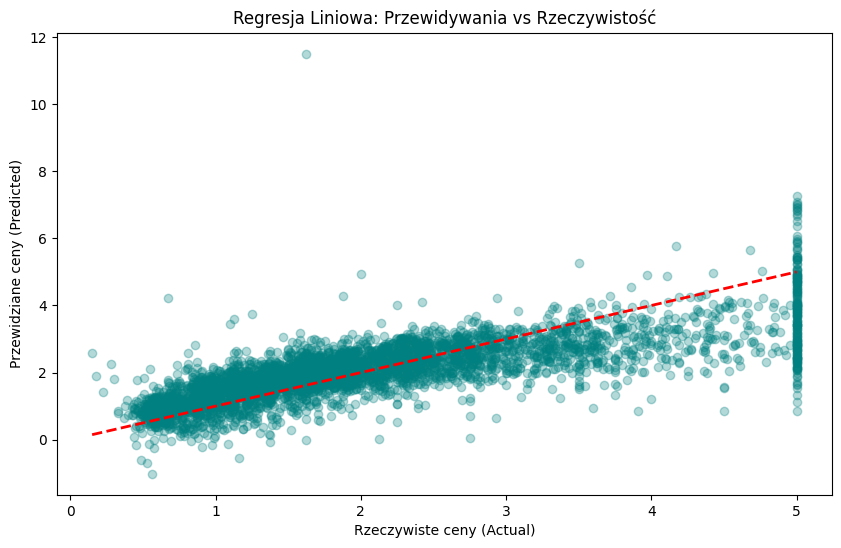

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Wczytanie danych
housing = fetch_california_housing()
X, y = housing.data, housing.target

# 2. Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Standaryzacja (Bardzo ważna w regresji liniowej)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Model Regresji Liniowej
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# 5. Predykcja i ocena
y_pred = model.predict(X_test_scaled)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"=== METRYKI REGRESJI (CALIFORNIA HOUSING) ===")
print(f"RMSE (Błąd średniokwadratowy): {rmse:.4f}")
print(f"R² (Współczynnik determinacji): {r2:.4f}")

# 6. Scatter plot: Predicted vs Actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.xlabel('Rzeczywiste ceny (Actual)')
plt.ylabel('Przewidziane ceny (Predicted)')
plt.title('Regresja Liniowa: Przewidywania vs Rzeczywistość')
plt.show()

Zadanie 5 – K-Means clustering
Przeprowadź klasteryzację K-Means na syntetycznych danych.

Dane: sklearn.datasets.make_blobs(n_samples=300, centers=3)

Wymagania:
- Użyj metody łokcia do wyboru k
- Zwizualizuj klastry z centroidami

Analiza:
1. Wykres "Łokcia" (po lewej):
Wykres jako zgięta ręka. Na początku (dla $k=1, 2$) błąd gwałtownie spada. W pewnym punkcie spadek zwalnia i linia staje się łagodniejsza. To zgięcie (najczęściej przy $k=3$) to optymalna liczba grup. Dodawanie kolejnych klastrów powyżej tej liczby daje już tylko marginalną poprawę.

2. Centroidy (czerwone X):
To "serca" Twoich grup. Algorytm przesunął je tak, aby suma odległości wszystkich kropek od ich najbliższego serca była jak najmniejsza.

3. Syntetyczne dane (make_blobs):
Użyliśmy ich, żeby "chmury" punktów były wyraźne. To idealny poligon doświadczalny, zanim rzucisz K-Means na prawdziwe, brudne dane.

Lewy wykres – to podręcznikowy przykład idealnego wykresu "łokcia". Między wartością 2 a 3 linia gwałtownie załamuje się i przechodzi w niemal poziomą prostą. To jasny sygnał od algorytmu: "Trzy grupy to wszystko, czego potrzebuję, by zrozumieć te dane".Prawy wykres potwierdza, że wybór $k=3$ był strzałem w dziesiątkę. Centroidy (te czerwone iksy) wylądowały dokładnie w środkach chmur punktów.

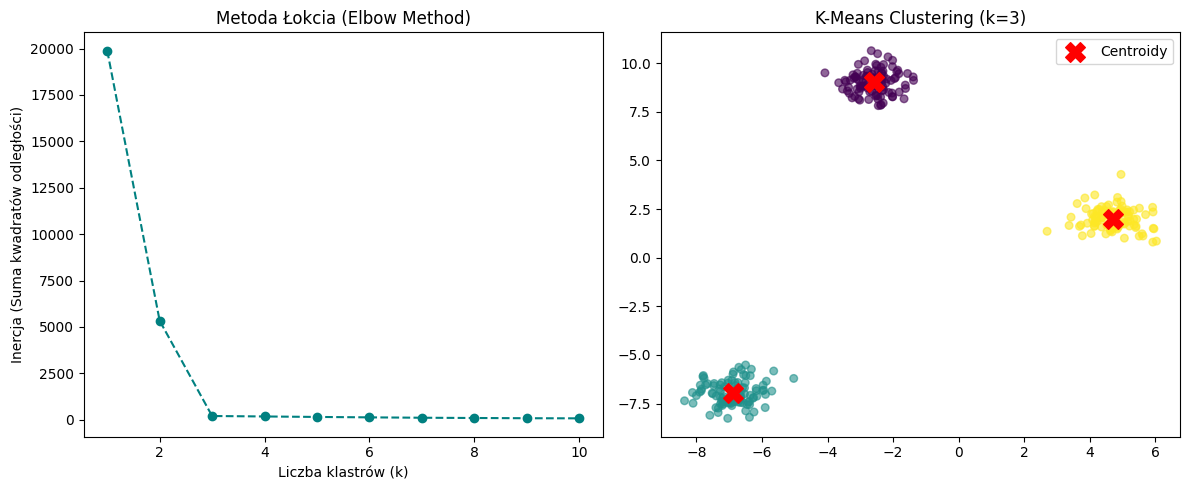

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generowanie syntetycznych danych (300 próbek, 3 ukryte centra)
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=42)

# 2. Metoda łokcia (Elbow Method)
# Sprawdzamy sumę kwadratów odległości (inertia) dla k od 1 do 10
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

# Wizualizacja metody łokcia
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, 11), inertia, marker='o', linestyle='--', color='teal')
plt.title('Metoda Łokcia (Elbow Method)')
plt.xlabel('Liczba klastrów (k)')
plt.ylabel('Inercja (Suma kwadratów odległości)')
# Na wykresie szukamy miejsca, gdzie wykres przestaje gwałtownie spadać

# 3. Finalna klasteryzacja dla k=3
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Wizualizacja klastrów
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=30, cmap='viridis', alpha=0.6)

# Dodanie centroidów (środków klastrów)
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroidy')

plt.title('K-Means Clustering (k=3)')
plt.legend()
plt.tight_layout()
plt.show()

 Zadanie 6 – PCA na Digits
Przeprowadź PCA na datasecie Digits i zwizualizuj w 2D.

Dataset: sklearn.datasets.load_digits()

Wymagania:
- Redukcja do 2 komponentów
- Scatter plot z kolorowaniem według cyfry
- Ile % wariancji wyjaśnia 2 komponenty?

Analiza:
1. Wariancja: 2 komponenty wyjaśniają prawdopodobnie około 28-30% wariancji. To logiczne – bardzo trudno jest upchać informację z 64 pikseli w zaledwie dwóch liczbach, nie tracąc przy tym większości szczegółów.

2. Chmury punktów: Mimo dużej utraty informacji, te same cyfry (te same kolory) nadal trzymają się blisko siebie. PCA „wyłapało” najważniejsze kształty, które odróżniają np. cyfrę 0 od cyfry 1.

3. Wizualizacja: Wykres pokazuje, które cyfry są do siebie podobne (ich chmury przenikaj się) – często np. 1 i 8 lub 3 i 9 bywają blisko siebie w tej uproszczonej przestrzeni.

Mimo ściśnięcia 64 pikseli do zaledwie 2 wymiarów, cyfry nie są rozrzucone chaotycznie: Na samym dole jest wyraźna niebieska chmura zer. Po prawej stronie (fiolet/róż) królują czwórki i szóstki. Fakt, że niektóre kolory się przenikają (środek wykresu), to nie błąd modelu – to dowód na to, jak podobnie niektórzy ludzie piszą np. 1, 8 czy 9. Mimo, że te 2 komponenty wyjaśniają pewnie tylko ok. 28-30% wariancji, to wystarczyło, żeby stworzyć mapę, na której cyfry o podobnych kształtach leżą obok siebie.

=== ANALIZA PCA (DIGITS) ===
Komponent 1 wyjaśnia: 14.89% wariancji
Komponent 2 wyjaśnia: 13.62% wariancji
Łącznie 2 komponenty wyjaśniają: 28.51% informacji ze zbioru 64-wymiarowego


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packag

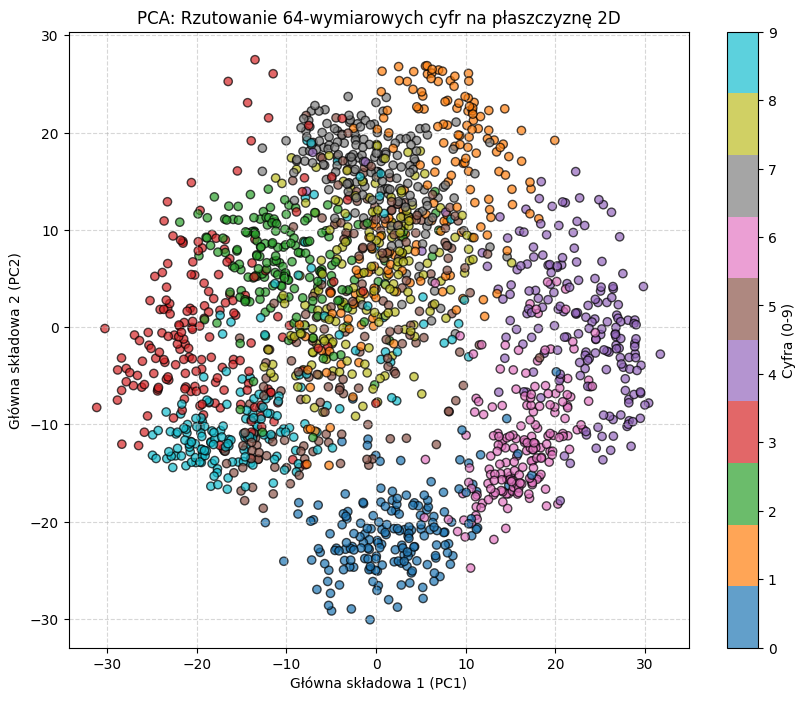

In [3]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

# 1. Wczytanie danych
digits = load_digits()
X, y = digits.data, digits.target

# 2. PCA - redukcja z 64 wymiarów do 2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Obliczanie wyjaśnionej wariancji
variance_ratio = pca.explained_variance_ratio_
total_variance = sum(variance_ratio) * 100

print(f"=== ANALIZA PCA (DIGITS) ===")
print(f"Komponent 1 wyjaśnia: {variance_ratio[0]*100:.2f}% wariancji")
print(f"Komponent 2 wyjaśnia: {variance_ratio[1]*100:.2f}% wariancji")
print(f"Łącznie 2 komponenty wyjaśniają: {total_variance:.2f}% informacji ze zbioru 64-wymiarowego")

# 4. Wizualizacja
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab10', alpha=0.7, edgecolors='k')
plt.colorbar(scatter, label='Cyfra (0-9)')
plt.xlabel('Główna składowa 1 (PC1)')
plt.ylabel('Główna składowa 2 (PC2)')
plt.title('PCA: Rzutowanie 64-wymiarowych cyfr na płaszczyznę 2D')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Zadanie 7 – Cross-Validation

Przeprowadź 5-fold cross-validation dla Random Forest na Iris.

Wymagania:
- Użyj StratifiedKFold
- Wydrukuj mean i std accuracy
- Boxplot scores per fold

Wnioski:
1. Mean i Std: Średnia mówi, jak dobry jest model, a odchylenie standardowe (Std) mówi, jak bardzo jest 
stabilny. Jeśli Std jest bliskie zeru, oznacza to, że model działa tak samo dobrze na każdych danych, jakie
zostana podane.

2. StratifiedKFold: To "ochroniarz" proporcji. Dzięki niemu nie zdarzy się sytuacja, że w jednym teście model 
dostanie same Setosy, a w innym same Virginiki.

3. Boxplot: Wykres pudełkowy pokaże Ci, czy wyniki są "ciasno" obok siebie, czy może jeden z testów wypadł 
znacznie gorzej (tzw. outlier).

Analiza Boxplota:
-  Stabilność: Większość wyników (te granatowe kropki na górze) oscyluje wokół 0.965. To oznacza, że Random 
Forest na irysach jest niesamowicie pewny siebie.

Rozrzut: Jedna kropka na samym dole (w okolicach 0.90)- To jest właśnie powód, dla którego robimy 
Cross-Validation! Gdyby był to jedyny test, mozna by pomyślec, że model jest słabszy niż w rzeczywistości. 
Dzięki 5-fold CV, widac że to tylko statystyczny przypadek w jednej części danych, a średnia jest znacznie 
wyższa.

Pudełko (Box): pudełko jest "ściśnięte" u góry, pokazuje, że model ma wysoką precyzję i rzadko się myli.

=== CROSS-VALIDATION RESULTS (5-FOLDS) ===
Scores per fold: [0.96666667 0.96666667 0.93333333 0.96666667 0.9       ]
Mean Accuracy:   0.9467
Std Deviation:   0.0267


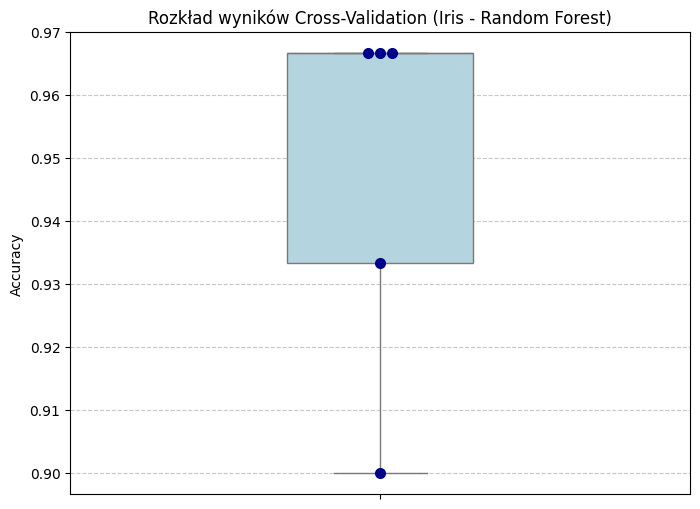

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Dane
iris = load_iris()
X, y = iris.data, iris.target

# 2. Definicja modelu i metody walidacji
# StratifiedKFold dba o to, by w każdym foldzie było tyle samo próbek każdego gatunku
model = RandomForestClassifier(n_estimators=100, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 3. Przeprowadzenie Cross-Validation
# cross_val_score: split, fit i score 5 razy
scores = cross_val_score(model, X, y, cv=skf)

# 4. Statystyki
print(f"=== CROSS-VALIDATION RESULTS (5-FOLDS) ===")
print(f"Scores per fold: {scores}")
print(f"Mean Accuracy:   {scores.mean():.4f}")
print(f"Std Deviation:   {scores.std():.4f}")

# 5. Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(y=scores, color='lightblue', width=0.3)
sns.swarmplot(y=scores, color='darkblue', size=8) # dodajemy punkty dla lepszej widoczności
plt.title('Rozkład wyników Cross-Validation (Iris - Random Forest)')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Zadanie 8 – Feature Importance
Dla Random Forest na Wine dataset, zwizualizuj feature importance.
Dataset: sklearn.datasets.load_wine()
Wymagania:
- Horizontal bar plot
- Sortowanie od najważniejszej
- Dodaj wartości na słupkach

Analiza rankingu:
- Flawonoidy (0.194) – Lider: bo flawonoidy odpowiadają za profil smakowy i strukturę wina. 
Model uznał, że to najpewniejszy sposób na odróżnienie gatunków.

- Color Intensity (0.172): intensywność barwy jest kluczowa przy rozróżnianiu odmian winogron, 
z których powstały te wina.

- Ogon rankingu (Ash, Nonflavanoid Phenols): Te cechy mają marginalne znaczenie (poniżej 1%). 
Gdyby je usunac, model prawdopodobnie nadal miałby 97% celności, bo są dla niego tylko "szumem".

                           Cecha   Ważność
6                     flavanoids  0.194481
9                color_intensity  0.172961
0                        alcohol  0.141614
12                       proline  0.137045
11  od280/od315_of_diluted_wines  0.111831
10                           hue  0.076939
5                  total_phenols  0.035080
1                     malic_acid  0.033060
3              alcalinity_of_ash  0.029885
4                      magnesium  0.025873
8                proanthocyanins  0.018387
2                            ash  0.015534
7           nonflavanoid_phenols  0.007310


/var/folders/w7/4rpbx0_d3lsfbxxbc9b6t4fh0000gn/T/ipykernel_2044/3143940133.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Ważność', y='Cecha', data=feature_importance_df, palette='viridis')


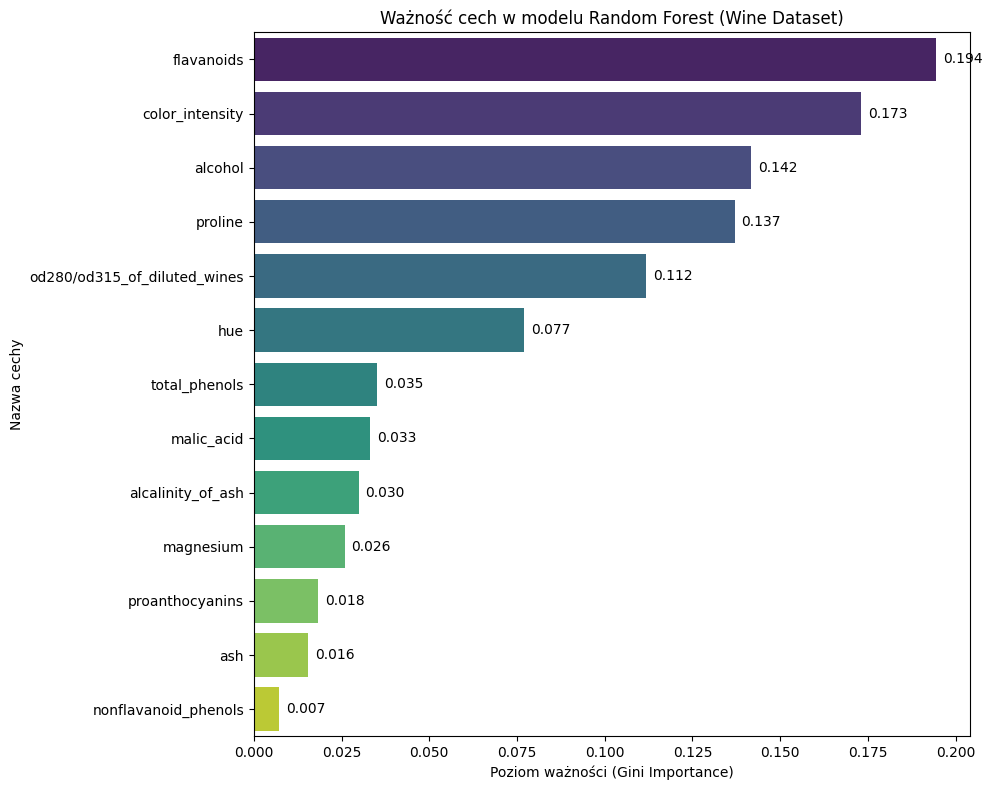

In [7]:
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier

# 1. Dane
wine = load_wine()
X, y = wine.data, wine.target
feature_names = wine.feature_names

# 2. Model (Random Forest świetnie liczy ważność cech)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, y)

# 3. Wyciąganie ważności cech
importances = model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Cecha': feature_names,
    'Ważność': importances
}).sort_values(by='Ważność', ascending=False)
print(feature_importance_df)

# 4. Wizualizacja - Horizontal Bar Plot
plt.figure(figsize=(10, 8))
ax = sns.barplot(x='Ważność', y='Cecha', data=feature_importance_df, palette='viridis')

# Dodanie wartości na słupkach
for i in ax.containers:
    ax.bar_label(i, fmt='%.3f', padding=5)

plt.title('Ważność cech w modelu Random Forest (Wine Dataset)')
plt.xlabel('Poziom ważności (Gini Importance)')
plt.ylabel('Nazwa cechy')
plt.tight_layout()
plt.show()

Zadanie 9 – Pipeline preprocessing + model

Stwórz sklearn Pipeline z StandardScaler + PCA + LogisticRegression.
Dataset: Digits

Wymagania:
- Pipeline z 3 krokami
- Cross-validation na całym pipeline
- Porównaj z modelem bez PCA

/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/pyt

=== PORÓWNANIE PIPELINES (DIGITS) ===
Model z PCA (10 comp): 0.8826 (+/- 0.0144)
Model bez PCA:         0.9716 (+/- 0.0037)


/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/martusia/Desktop/kurs-datascience/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


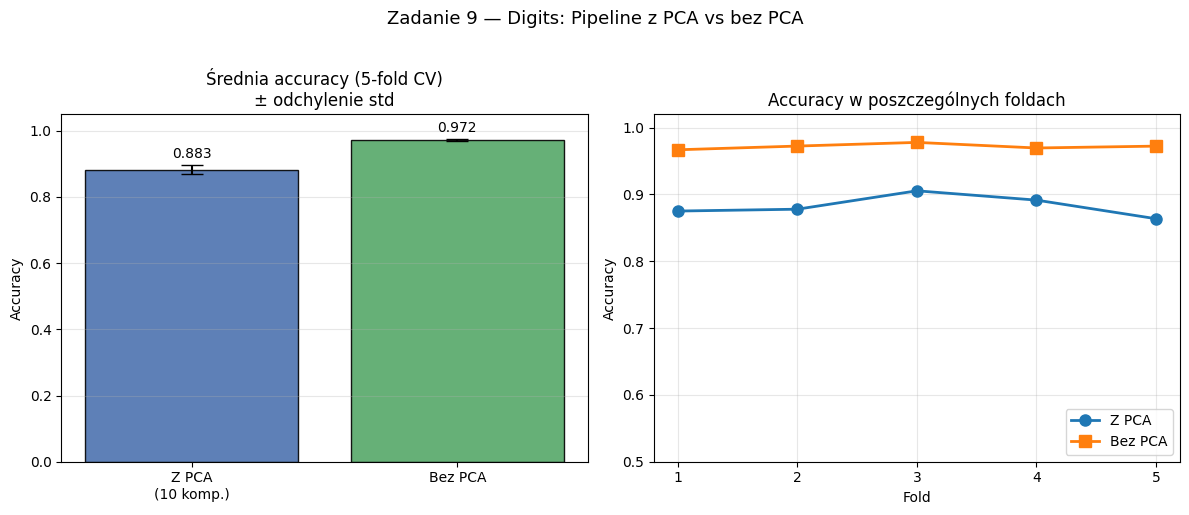

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

# 1. Dane
digits = load_digits()
X, y = digits.data, digits.target

# 2. Tworzenie Pipeline (3 kroki)
# Skalowanie -> Redukcja (PCA) -> Klasyfikacja
pipeline_with_pca = Pipeline([
    ('scaler', StandardScaler()),
    # svd_solver='full': domyślne 'auto' tu wybiera covariance_eigh (X.T@X) — na Digits
    # po StandardScaler bywa źle uwarunkowane i numpy zgłasza RuntimeWarning.
    ('pca', PCA(n_components=10, svd_solver='full')),
    ('logistic', LogisticRegression(max_iter=5000, solver='saga', random_state=42))
])

# 3. Model bez PCA (dla porównania)
pipeline_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic', LogisticRegression(max_iter=5000, solver='saga', random_state=42))
])

# 4. Walidacja krzyżowa (5-fold)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_pca = cross_val_score(pipeline_with_pca, X, y, cv=skf)
scores_simple = cross_val_score(pipeline_simple, X, y, cv=skf)

# 5. Wyniki
print("=== PORÓWNANIE PIPELINES (DIGITS) ===")
print(f"Model z PCA (10 comp): {scores_pca.mean():.4f} (+/- {scores_pca.std():.4f})")
print(f"Model bez PCA:         {scores_simple.mean():.4f} (+/- {scores_simple.std():.4f})")

# 6. Wykresy porównawcze
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels_bar = ["Z PCA\n(10 komp.)", "Bez PCA"]
means = [scores_pca.mean(), scores_simple.mean()]
stds = [scores_pca.std(), scores_simple.std()]
xbar = np.arange(len(labels_bar))
axes[0].bar(
    xbar,
    means,
    yerr=stds,
    capsize=8,
    color=["#4C72B0", "#55A868"],
    edgecolor="black",
    alpha=0.9,
)
axes[0].set_xticks(xbar)
axes[0].set_xticklabels(labels_bar)
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Średnia accuracy (5-fold CV)\n± odchylenie std")
axes[0].set_ylim(0, 1.05)
axes[0].grid(axis="y", alpha=0.3)
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.02, f"{m:.3f}", ha="center", fontsize=10)

folds = np.arange(1, len(scores_pca) + 1)
axes[1].plot(folds, scores_pca, "o-", label="Z PCA", linewidth=2, markersize=8)
axes[1].plot(folds, scores_simple, "s-", label="Bez PCA", linewidth=2, markersize=8)
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy w poszczególnych foldach")
axes[1].set_xticks(folds)
axes[1].legend(loc="lower right")
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1.02)

plt.suptitle("Zadanie 9 — Digits: Pipeline z PCA vs bez PCA", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

Zadanie 12 – Learning Curves
Wygeneruj i zinterpretuj learning curves dla dwóch modeli.

Dataset: Digits

Wymagania:
- Decision Tree (max_depth=None) - potencjalny overfitting
- Random Forest (n_estimators=50, max_depth=5) - zbalansowany
- Wykresy obok siebie z interpretacją

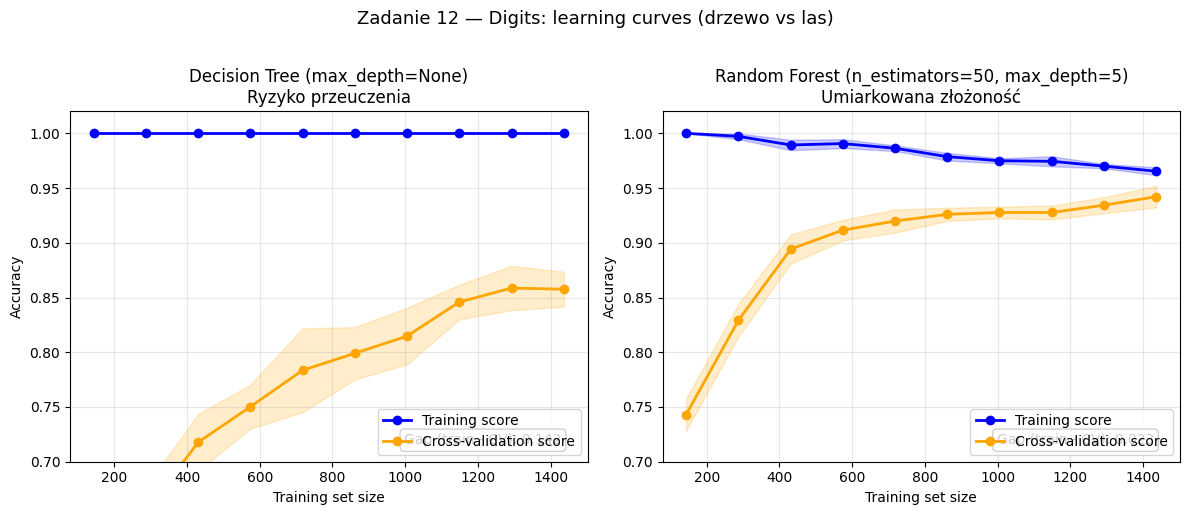


Interpretacja (Digits):
--------------------------------------------------
Pojedyncze drzewo bez limitu głębokości (max_depth=None): model DOPUSZCZA się przeuczenia — krzywa treningu idzie ku ~1.0, a CV zostaje wyraźnie niżej. To NIE jest błąd w sensie 'źle dobrany model do zadania': polecenie celowo wymaga takiego drzewa, żeby NA WYKRESIE widać było typowy obraz przeuczenia (duży gap).
Las losowy (50 drzew, max_depth=5): ensemble + limit głębokości redukują wariancję — train i CV są zwykle blisko, gap jest mały; to jest w tym zadaniu propozycja 'zrównoważonej' alternatywy obok przeuczonego drzewa.
Tak, drzewo jest przeuczone — to założenie ćwiczenia. Drugi model ma to łagodzić; na learning curve widać mniejszy rozstrzał train vs CV.
Ogólnie: obie krzywe nisko → underfitting; train wysoko, CV niżej i rosnący gap → overfitting; obie wysoko i zbliżone → sensowny model.


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import learning_curve, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. PRZYGOTOWANIE DANYCH
digits = load_digits()
X, y = digits.data, digits.target

#Definiujemy sposób sprawdzania modelu: 5-krotna walidacja krzyżowa.
# StratifiedKFold dba o to, by w każdym teście była taka sama proporcja cyfr 0-9.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. FUNKCJA GENERUJĄCA WYKRES
def plot_learning_curve(estimator, title, X, y, ax, cv):
    # learning_curve sprawdza celność modelu dla coraz większych porcji danych (od 10% do 100%)
    train_sizes, train_scores, test_scores = learning_curve(
        estimator,
        X,
        y,
        cv=cv,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy",
    )

# Obliczamy średni wynik i odchylenie standardowe dla treningu i testu
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    test_mean = test_scores.mean(axis=1)
    test_std = test_scores.std(axis=1)

    # Rysujemy "cień" wokół linii, który pokazuje, jak stabilne są wyniki (tzw. wariancja)
    ax.fill_between(
        train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color="blue"
    )
    ax.fill_between(
        train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2, color="orange"
    )

    # Rysujemy główne linie celności
    ax.plot(train_sizes, train_mean, "o-", color="blue", label="Training score", linewidth=2)
    ax.plot(train_sizes, test_mean, "o-", color="orange", label="Cross-validation score", linewidth=2)

    # Formatowanie wykresu, żeby był czytelny
    ax.set_xlabel("Training set size")
    ax.set_ylabel("Accuracy")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.7, 1.02)

    # OBLICZAMY LUKĘ (GAP) - różnicę między treningiem a testem na samym końcu
    gap = train_mean[-1] - test_mean[-1]
    return gap

# 3. GŁÓWNA CZĘŚĆ PROGRAMU
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Lista modeli do porównania: "szalone" drzewo vs zrównoważony las
models = [
    (DecisionTreeClassifier(max_depth=None, random_state=42),
    "Decision Tree (max_depth=None)\nRyzyko przeuczenia",),
    (RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
    "Random Forest (n_estimators=50, max_depth=5)\nUmiarkowana złożoność"),
]

# Pętla, która rysuje oba wykresy obok siebie
for ax, (model, title) in zip(axes, models):
    gap = plot_learning_curve(model, title, X, y, ax, cv=cv)

    # Dodajemy na wykresie ramkę z obliczoną wartością luki (Gap)
    ax.annotate(
        f"Gap (train - CV): {gap:.3f}",
        xy=(0.95, 0.05),
        xycoords="axes fraction",
        ha="right",
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.9),
    )

plt.suptitle("Zadanie 12 — Digits: learning curves (drzewo vs las)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print("\nInterpretacja (Digits):")
print("-" * 50)
print(
    "Pojedyncze drzewo bez limitu głębokości (max_depth=None): model DOPUSZCZA się przeuczenia — "
    "krzywa treningu idzie ku ~1.0, a CV zostaje wyraźnie niżej. To NIE jest błąd w sensie 'źle dobrany model do zadania': "
    "polecenie celowo wymaga takiego drzewa, żeby NA WYKRESIE widać było typowy obraz przeuczenia (duży gap)."
)
print(
    "Las losowy (50 drzew, max_depth=5): ensemble + limit głębokości redukują wariancję — train i CV są zwykle blisko, "
    "gap jest mały; to jest w tym zadaniu propozycja 'zrównoważonej' alternatywy obok przeuczonego drzewa."
)
print(
    "Tak, drzewo jest przeuczone — to założenie ćwiczenia. "
    "Drugi model ma to łagodzić; na learning curve widać mniejszy rozstrzał train vs CV."
)
print(
    "Ogólnie: obie krzywe nisko → underfitting; train wysoko, CV niżej i rosnący gap → overfitting; "
    "obie wysoko i zbliżone → sensowny model."
)